<a href="https://colab.research.google.com/github/Anagha-P14/Trend-Analysis/blob/main/Trend_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#TASK 1 — Fetch Lemmy Data (JSON)
#Use Lemmy API (no auth needed for basic)
#Fetch trending posts
import requests
import os
import json

url = "https://lemmy.ml/api/v3/post/list?sort=TopAll&limit=50"

response = requests.get(url)

posts = []

if response.status_code == 200:
    data = response.json()
    if 'error' in data: # Check if the response itself is an API error
        print(f"Lemmy API Error: {data['message']}")
    elif 'posts' in data: # Proceed if 'posts' key exists
        for post in data["posts"]:
            posts.append({
                "title": post["post"]["name"],
                "score": post["counts"]["score"],
                "comments": post["counts"]["comments"]
            })
        print(posts[:5])
        # Create the 'data' directory if it doesn't exist
        os.makedirs("data", exist_ok=True)
        with open("data/raw_data.json", "w") as f:
          json.dump(posts, f, indent=4)
    else:
        print("Unexpected API response format:")
        print(data)
else:
    print(f"HTTP Error: {response.status_code}")
    print(response.text)

[{'title': 'Winning is relative', 'score': 3664, 'comments': 305}, {'title': 'F#€k $pez', 'score': 3441, 'comments': 364}, {'title': 'What is the biggest lesson that employment has taught you?', 'score': 3253, 'comments': 591}, {'title': 'Lemmy.ml has now blocked threads.net / Meta', 'score': 3118, 'comments': 476}, {'title': 'It either runs on Linux or refund', 'score': 3088, 'comments': 334}]


In [2]:
pip install better-profanity

In [3]:
#TASK 2 — Clean Data (Pandas → CSV)
# What to do:
#Load JSON
#Remove missing/null values
#Convert into DataFrame
#Apply profanity filter
#Filter specific title
#Save as CSV

import pandas as pd
import os
from better_profanity import profanity

# Load censor words
profanity.load_censor_words()

print("Current directory:", os.getcwd())
print("Files in data folder:", os.listdir("data") if os.path.exists("data") else "No data folder")

df = pd.read_json("data/raw_data.json")

# Cleaning
df = df.dropna()
df = df[df["score"] > 0]

# Apply profanity filter to the 'title' column
df['title'] = df['title'].apply(lambda x: profanity.censor(x))

# Filter out specific title
df = df[df['title'] != 'F#€k $pez']

df.to_csv("data/clean_data.csv", index=False)

Current directory: /content
Files in data folder: ['raw_data.json', 'clean_data.csv']


In [4]:

#TASK 3 — Analyse Data (NumPy + Pandas)
#What to analyse:
#Average score
#Most commented post
#Top 5 posts (by comments)

import pandas as pd
import numpy as np

df = pd.read_csv("data/clean_data.csv")

print("Average Score:", np.mean(df["score"]))

top_post = df.loc[df["score"].idxmax()]
print("Top Post (by score):", top_post["title"])

# Change to top 5 posts by comments instead of score
top5 = df.sort_values(by="comments", ascending=False).head(5)
print("\nTop 5 Most Commented Posts:")
print(top5)

Average Score: 2433.183673469388
Top Post (by score): Winning is relative

Top 5 Most Commented Posts:
                                                title  score  comments
10               Are you replacing Reddit with Lenny?   2610       943
30                     Do your part, try not to lurk!   2216       868
39  How many people actually dropped Reddit for Le...   2137       808
22  Google engineers want to introduce DRMs for we...   2376       796
18                            Madison on why she quit   2466       685


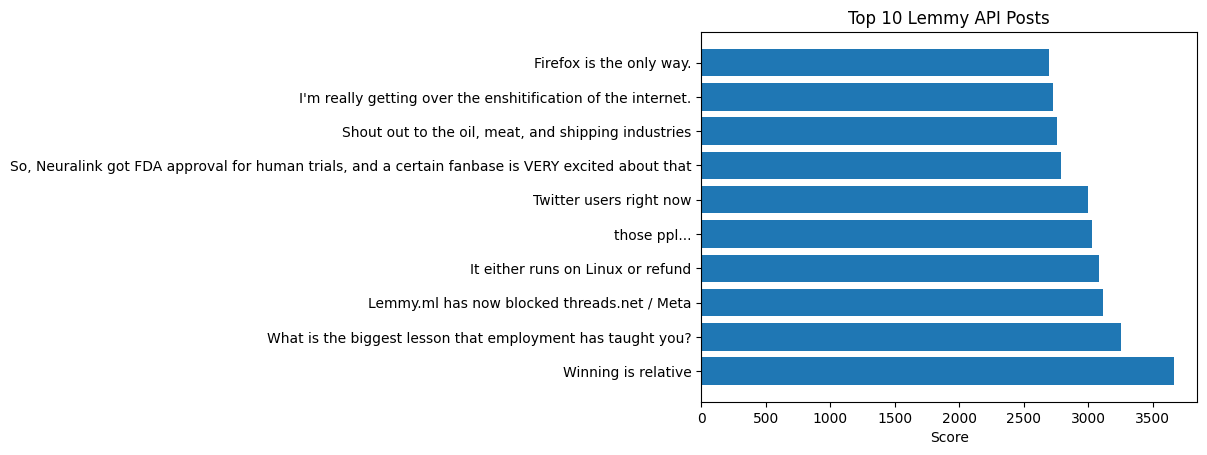

In [5]:

#TASK 4 — Visualization (Matplotlib)
#Charts to create:
#Bar chart → Top 10 posts
#Histogram → Score distribution


import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/clean_data.csv")

top10 = df.sort_values(by="score", ascending=False).head(10)

plt.figure()
plt.barh(top10["title"], top10["score"])
plt.xlabel("Score")
plt.title("Top 10 Lemmy API Posts")
plt.show()